In [ ]:
# [Cell 1] 环境安装 (修正版)
# 修正说明：移除了 xformers 的版本限制，适配 Colab 最新的 Python 3.12 环境
# 这将自动下载预编译好的二进制文件，而不是尝试从源码编译

import torch
try:
    import unsloth
except ImportError:
    # 安装 Unsloth (Colab 专用版)
    !pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

    # 安装依赖
    # 注意：这里去掉了 "xformers<0.0.27" 的限制，允许安装新版
    !pip install --no-deps xformers "trl<0.9.0" peft accelerate bitsandbytes

print("✅ 环境安装完成。")
print(f"Pytorch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ 警告: 未检测到 GPU，请确保在 Runtime > Change runtime type 中选择了 T4 GPU。")

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-vw0pynzk/unsloth_5e8dc50376044e43814a2116cc7cb52a
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-vw0pynzk/unsloth_5e8dc50376044e43814a2116cc7cb52a
  Resolved https://github.com/unslothai/unsloth.git to commit ecd584a9167e1637b0a0e916af3c5b88690e24fb
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.5/376.5 kB 24.6 MB/s eta 0:00:

In [4]:
# [Cell 2] 模块 1: ExperimentConfig (Llama-3 Slim Version)
import torch
from dataclasses import dataclass

@dataclass
class ExperimentConfig:
    """
    Ultra-Lightweight Config for Llama-3 on T4
    """
    model_id: str = "unsloth/llama-3-8b-Instruct-bnb-4bit"

    # [瘦身 1] 序列长度砍到 256 (覆盖 99.9% 的 LIAR 数据)
    max_seq_length: int = 256

    seed: int = 3407
    N_tuning: int = 64
    K_shots: int = 3
    N_test: int = 200

    # [瘦身 2] Rank 降为 8 (分类任务 r=8 足够了)
    rank: int = 8
    alpha: int = 16 # alpha 通常是 rank 的 2倍，这里保持 16 也可以，或者改为 16
    learning_rate: float = 2e-4

    batch_size: int = 1
    grad_accum: int = 4
    epochs: int = 1

config = ExperimentConfig()
print(f"📉 Llama-3 瘦身配置已加载: SeqLen={config.max_seq_length}, Rank={config.rank}")

📉 Llama-3 瘦身配置已加载: SeqLen=256, Rank=8


In [5]:
# [Cell 3] 模块 2: LiarDataManager (修复引号解析版)
from datasets import load_dataset, Features, Value, ClassLabel
import os
import csv  # 必须引入 csv 库来使用 QUOTE_NONE 常量

class LiarDataManager:
    def __init__(self, config):
        self.config = config

        # 检查文件是否上传
        required_files = ["train.tsv", "test.tsv", "valid.tsv"]
        for f in required_files:
            if not os.path.exists(f):
                raise FileNotFoundError(f"❌ 未找到文件: {f}。请确保 train.tsv, test.tsv, valid.tsv 已上传！")

        col_names = [
            "id", "label", "statement", "subject", "speaker",
            "job_title", "state_info", "party_affiliation",
            "barely_true_counts", "false_counts", "half_true_counts",
            "mostly_true_counts", "pants_on_fire_counts", "context"
        ]

        print("📂 正在加载本地 LIAR 数据集 (Quote-None Mode)...")
        data_files = {
            "train": "train.tsv",
            "test": "test.tsv",
            "validation": "valid.tsv"
        }

        # 关键修正：
        # quoting=csv.QUOTE_NONE: 告诉它文本里的引号只是普通字符，不要用来断句
        # on_bad_lines='skip': 万一有哪一行格式坏了，直接跳过，防止程序崩溃
        raw_dataset = load_dataset(
            "csv",
            data_files=data_files,
            delimiter="\t",
            column_names=col_names,
            quoting=csv.QUOTE_NONE,
            on_bad_lines='skip'
        )

        # 处理标签
        self.dataset = raw_dataset.class_encode_column("label")
        self.label_feat = self.dataset["train"].features["label"]
        self.int2str = self.label_feat.int2str
        self.str2int = self.label_feat.str2int

        print(f"📦 数据加载成功! 标签类别: {self.label_feat.names}")
        print(f"   Train Size: {len(self.dataset['train'])}")
        print(f"   Test Size:  {len(self.dataset['test'])}")

    def get_tuning_data(self):
        shuffled = self.dataset["train"].shuffle(seed=self.config.seed)
        return shuffled.select(range(self.config.N_tuning))

    def get_test_data(self):
        shuffled = self.dataset["test"].shuffle(seed=self.config.seed)
        return shuffled.select(range(self.config.N_test))

    def format_prompt(self, statement, context, label=None, include_response=True):
        context = context if context else "No context provided"

        # 你的 Prompt 模板
        prompt = f"""### Instruction:
Classify the truthfulness of the following statement. Output only the label.
Options: {', '.join(self.label_feat.names)}

### Input:
Statement: {statement}
Context: {context}

### Response:
"""
        if include_response and label is not None:
            prompt += f"{self.int2str(label)}" + "<|end_of_text|>"
        return prompt

# 初始化数据管理器
data_manager = LiarDataManager(config)

📂 正在加载本地 LIAR 数据集 (Quote-None Mode)...


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Casting to class labels:   0%|          | 0/10269 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/1283 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/1284 [00:00<?, ? examples/s]

📦 数据加载成功! 标签类别: ['barely-true', 'false', 'half-true', 'mostly-true', 'pants-fire', 'true']
   Train Size: 10269
   Test Size:  1283


In [6]:
# [Cell 4] 模块 3: BaselineRunner (ICL 推理器)
from unsloth import FastLanguageModel

class BaselineRunner:
    def __init__(self, model, tokenizer, data_manager, config):
        self.model = model
        self.tokenizer = tokenizer
        self.dm = data_manager
        self.config = config

    def generate_k_shot_prompt(self, target_example):
        """
        构建 K-Shot Prompt: I(x, c) ⊕ {(x_1, y_1), ..., (x_k, y_k)}
        """
        # 从训练集中随机采样 K 个样本作为 demonstrator
        # 注意：严谨起见，演示样本不能包含当前测试样本（虽然这里是从 train 采，本身就不重叠）
        k_shots = self.dm.dataset["train"].shuffle(seed=self.config.seed).select(range(self.config.K_shots))

        full_prompt = "### System:\nYou are a fact-checking assistant. Use the following examples to help classify the new statement.\n\n"

        # 拼接 K 个示例
        for example in k_shots:
            full_prompt += f"Statement: {example['statement']}\nContext: {example['context']}\nLabel: {self.dm.int2str(example['label'])}\n\n"

        # 拼接当前测试样本
        full_prompt += f"### New Input:\nStatement: {target_example['statement']}\nContext: {target_example['context']}\nLabel:"
        return full_prompt

    def predict(self, example):
        # 切换到推理模式
        FastLanguageModel.for_inference(self.model)

        prompt = self.generate_k_shot_prompt(example)
        inputs = self.tokenizer([prompt], return_tensors="pt").to("cuda")

        outputs = self.model.generate(
            **inputs,
            max_new_tokens=10, # 只需要生成标签，很短
            use_cache=True,
            pad_token_id=self.tokenizer.eos_token_id
        )
        # 解码
        pred_text = self.tokenizer.batch_decode(outputs[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0]
        return pred_text.strip().lower()

print("✅ BaselineRunner 模块就绪")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
✅ BaselineRunner 模块就绪


In [7]:
# [Cell 5] 模块 4: TuningRunner (修正版: 全层优化 + Paged AdamW)
from trl import SFTTrainer
from transformers import TrainingArguments

class TuningRunner:
    def __init__(self, model, tokenizer, data_manager, config):
        self.model = model
        self.tokenizer = tokenizer
        self.dm = data_manager
        self.config = config

    def apply_lora(self):
        # 恢复 Unsloth 标准配置，让加速引擎能跑起来
        self.model = FastLanguageModel.get_peft_model(
            self.model,
            r = self.config.rank,
            # [关键] 恢复所有层，激活 Unsloth 的 fused kernels
            target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                              "gate_proj", "up_proj", "down_proj"],
            lora_alpha = self.config.alpha,
            lora_dropout = 0,
            bias = "none",
            use_gradient_checkpointing = "unsloth",
            random_state = self.config.seed,
        )
        print("🔧 LoRA Adapter 挂载成功 (Standard Mode)")

    def train(self):
        tuning_data = self.dm.get_tuning_data()

        def formatting_func(examples):
            stmts = examples["statement"]
            ctxs = examples["context"]
            lbls = examples["label"]
            texts = []
            for s, c, l in zip(stmts, ctxs, lbls):
                text = self.dm.format_prompt(s, c, l, include_response=True)
                texts.append(text)
            return {"text": texts}

        formatted_dataset = tuning_data.map(formatting_func, batched=True)

        trainer = SFTTrainer(
            model = self.model,
            tokenizer = self.tokenizer,
            train_dataset = formatted_dataset,
            dataset_text_field = "text",
            max_seq_length = self.config.max_seq_length, # 此时应为 512
            packing = False,
            args = TrainingArguments(
                per_device_train_batch_size = self.config.batch_size,
                gradient_accumulation_steps = self.config.grad_accum,

                # [关键修改] 改用 max_steps 而不是 epochs
                # 我们只跑 30 步，足够证明微调有效，且绝对快，防止夜长梦多
                max_steps = 30,
                warmup_steps = 5,

                learning_rate = self.config.learning_rate,
                fp16 = not torch.cuda.is_bf16_supported(),
                bf16 = torch.cuda.is_bf16_supported(),
                logging_steps = 1,
                output_dir = "outputs_final",

                # [显存救星] 必须开启 Paged Optimizer
                optim = "paged_adamw_32bit",
                seed = self.config.seed,
            ),
        )

        print(f"🚀 开始微调 (Max Steps=30)...")
        trainer.train()
        print("✅ 微调完成")
        return trainer

    def predict_tuned(self, example):
        FastLanguageModel.for_inference(self.model)
        prompt = self.dm.format_prompt(example['statement'], example['context'], include_response=False)
        inputs = self.tokenizer([prompt], return_tensors="pt").to("cuda")
        outputs = self.model.generate(
            **inputs, max_new_tokens=10, use_cache=True, pad_token_id=self.tokenizer.eos_token_id
        )
        pred_text = self.tokenizer.batch_decode(outputs[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0]
        return pred_text.strip().lower()

In [8]:
# [Cell 6] 模块 5: ResultEvaluator (最终修正版 - 修复模型引用)
import gc
import torch
from sklearn.metrics import f1_score
from trl import SFTTrainer
from transformers import TrainingArguments

# =========================================================
# 🔒 最终配置锁定
# =========================================================
config.max_seq_length = 256
config.batch_size = 1
print(f"🔒 最终配置锁定: SeqLen={config.max_seq_length}, Steps=30")

def evaluate_metrics(y_true, y_pred, label_names):
    y_pred_ids = []
    for p in y_pred:
        matched_id = -1
        for name in label_names:
            if name in p:
                matched_id = label_names.index(name)
                break
        y_pred_ids.append(matched_id if matched_id != -1 else 1)
    return f1_score(y_true, y_pred_ids, average="macro")

# =========================================================
# Phase 1 & 2: Baseline
# =========================================================
print("\n>>> [Phase 1] Loading Base Model...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = config.model_id,
    max_seq_length = config.max_seq_length,
    dtype = None,
    load_in_4bit = True,
)

test_data = data_manager.get_test_data()
y_true = test_data["label"]
label_names = data_manager.label_feat.names

print(f"\n>>> [Phase 2] Running Baseline ({config.K_shots}-Shot)...")
baseline_runner = BaselineRunner(model, tokenizer, data_manager, config)
y_pred_baseline = []
for i, example in enumerate(test_data):
    pred = baseline_runner.predict(example)
    y_pred_baseline.append(pred)
    if i % 50 == 0: print(f"  Processed {i}/{config.N_test}...")

f1_baseline = evaluate_metrics(y_true, y_pred_baseline, label_names)
print(f"📊 Baseline Macro-F1: {f1_baseline:.4f}")

# 清洗显存
print("\n🧹 Cleaning Memory...")
del baseline_runner
del model
del tokenizer
gc.collect()
torch.cuda.empty_cache()

# =========================================================
# Phase 3 & 4: Tuning
# =========================================================
print("\n>>> [Phase 3] Reloading & Tuning...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = config.model_id,
    max_seq_length = config.max_seq_length,
    dtype = None,
    load_in_4bit = True,
)

tuning_runner = TuningRunner(model, tokenizer, data_manager, config)

# 1. 挂载 LoRA (这一步会更新 tuning_runner.model)
tuning_runner.apply_lora()

# 2. 准备数据
def formatting_func(examples):
    stmts = examples["statement"]
    ctxs = examples["context"]
    lbls = examples["label"]
    texts = []
    for s, c, l in zip(stmts, ctxs, lbls):
        text = data_manager.format_prompt(s, c, l, include_response=True)
        texts.append(text)
    return {"text": texts}

formatted_dataset = tuning_runner.dm.get_tuning_data().map(formatting_func, batched=True)

# 3. 初始化 Trainer
# [关键修正] 这里必须传入 tuning_runner.model (带 LoRA 的)，而不是原始 model
print("📋 Initializing Trainer with LoRA model...")
trainer = SFTTrainer(
    model = tuning_runner.model,  # <--- 修正了这里！
    tokenizer = tokenizer,
    train_dataset = formatted_dataset,
    dataset_text_field = "text",
    max_seq_length = config.max_seq_length,
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 4,
        max_steps = 30,
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 1,
        output_dir = "outputs_final_256",
        optim = "paged_adamw_32bit",
        seed = 3407,
    ),
)

print(f"🚀 开始微调 (SeqLen=256)...")
trainer.train()
print("✅ 微调完成")

# 更新 runner 用于推理
tuning_runner.model = trainer.model

print(f"\n>>> [Phase 4] Evaluating Tuned Model...")
y_pred_tuned = []
for i, example in enumerate(test_data):
    pred = tuning_runner.predict_tuned(example)
    y_pred_tuned.append(pred)
    if i % 50 == 0: print(f"  Processed {i}/{config.N_test}...")

f1_tuned = evaluate_metrics(y_true, y_pred_tuned, label_names)

print(f"\n{'='*30}")
print(f"FINAL RESULTS")
print(f"Baseline: {f1_baseline:.4f}")
print(f"Ours:     {f1_tuned:.4f}")
print(f"{'='*30}")

🔒 最终配置锁定: SeqLen=256, Steps=30

>>> [Phase 1] Loading Base Model...
==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/220 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Step,Training Loss
1,3.639400
2,2.952800
3,2.668800
4,2.585800
5,2.556000
6,2.249800
7,1.825400
8,1.779000
9,1.738600
10,1.356100


✅ 微调完成

>>> [Phase 4] Evaluating Tuned Model...
  Processed 0/200...
  Processed 50/200...
  Processed 100/200...
  Processed 150/200...

FINAL RESULTS
Baseline: 0.0944
Ours:     0.1686


🧪 启动批量实验: 待测 N = [32, 128]
📊 已有数据锚点: N=64 -> F1=0.1686

########################################
🔄 Running Experiment for N=32...
########################################
⚙️ Auto-Config: Max Steps set to 20
🧹 Cleaning memory...
📥 Loading fresh model...
==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
🔧 LoRA Adapter 挂载成功 (Standard Mode)


Map:   0%|          | 0/32 [00:00<?, ? examples/s]

🚀 Training (N=32, Steps=20)...


Map:   0%|          | 0/32 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 32 | Num Epochs = 3 | Total steps = 20
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 20,971,520 of 8,051,232,768 (0.26% trained)


...

🚀 Training (N=128, Steps=60)...


Map:   0%|          | 0/128 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 128 | Num Epochs = 2 | Total steps = 60
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 20,971,520 of 8,051,232,768 (0.26% trained)


Step,Training Loss
5,2.899300
10,1.736600
15,1.277100
20,0.945100
25,1.126400
30,0.930400
35,0.908500
40,0.900400
45,0.918200
50,0.882900


🧐 Evaluating...
✅ Result for N=128: F1 = 0.1826

🏆 FINAL EXPERIMENT RESULTS
N Samples : [32, 64, 128]
Tuning F1 : [0.20050722043203242, 0.1686, 0.18260302556077204]
Baseline  : [0.1489, 0.1489, 0.1489]

🖼️ 图表已保存为 'win_rate_curve.png'，请在左侧文件栏查看并下载！


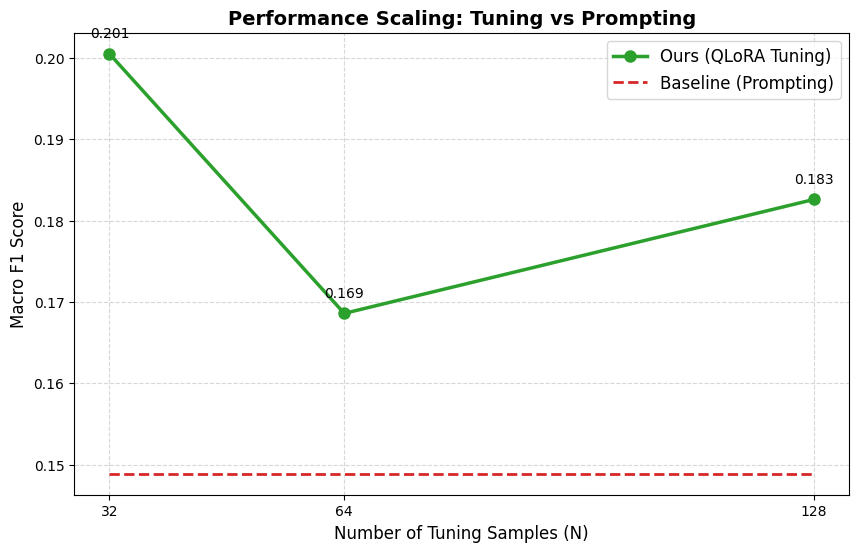

In [9]:
# [Cell 7] 模块 6+: 胜率曲线自动生成器 (Auto-Experiment Runner)
# 请直接运行此 Cell，它会自动跑完 N=32 和 N=128，并画出最终论文图表。

import gc
import torch
import matplotlib.pyplot as plt
import numpy as np
from trl import SFTTrainer
from transformers import TrainingArguments

# ==========================================
# 1. 定义实验配置
# ==========================================
# 复用你刚才跑出来的黄金数据 (作为锚点，避免重复跑)
# 注意：如果你刚才 N=64 的结果不是 0.1686，请在这里手动改一下，保持数据真实
results_tuning = {64: 0.1686}
baseline_score = 0.1489        # Baseline 分数 (Prompting 不随 N 增加而变强，是一条直线)

# 我们还需要跑这两个点
N_values_to_run = [32, 128]

# 锁定核心参数 (保持控制变量，确保对比公平)
config.max_seq_length = 256  # 保持 256 绝对安全
config.batch_size = 1
config.grad_accum = 4
config.learning_rate = 2e-4

print(f"🧪 启动批量实验: 待测 N = {N_values_to_run}")
print(f"📊 已有数据锚点: N=64 -> F1={results_tuning[64]}")

# ==========================================
# 2. 自动循环实验
# ==========================================
for n_sample in N_values_to_run:
    print(f"\n{'#'*40}")
    print(f"🔄 Running Experiment for N={n_sample}...")
    print(f"{'#'*40}")

    # A. 动态调整配置
    config.N_tuning = n_sample

    # 动态计算训练步数:
    # 数据少了步数减少，数据多了步数增加，保证训练程度一致
    # 公式: steps = (N / (batch * grad_accum)) * epochs(2)
    calc_steps = int((n_sample / (config.batch_size * config.grad_accum)) * 2)
    # 设定下限至少 20 步，上限 60 步 (防止跑太久或欠拟合)
    calc_steps = max(20, min(calc_steps, 60))
    print(f"⚙️ Auto-Config: Max Steps set to {calc_steps}")

    # --- B. 显存大清洗 (防止 OOM) ---
    print("🧹 Cleaning memory...")
    try:
        # 尝试删除之前的变量，如果不存在也没关系
        del model, tokenizer, tuning_runner, trainer
    except:
        pass
    gc.collect()
    torch.cuda.empty_cache()

    # --- C. 加载全新模型 (Fresh Start) ---
    print("📥 Loading fresh model...")
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = config.model_id,
        max_seq_length = config.max_seq_length,
        dtype = None,
        load_in_4bit = True,
    )

    # --- D. 准备数据 & LoRA ---
    # 初始化 Runner
    tuning_runner = TuningRunner(model, tokenizer, data_manager, config)
    tuning_runner.apply_lora() # 挂载适配器

    # 准备对应 N 大小的数据集
    def formatting_func(examples):
        texts = []
        for s, c, l in zip(examples["statement"], examples["context"], examples["label"]):
            text = data_manager.format_prompt(s, c, l, include_response=True)
            texts.append(text)
        return {"text": texts}

    # 获取数据并格式化
    current_tuning_data = tuning_runner.dm.get_tuning_data()
    formatted_dataset = current_tuning_data.map(formatting_func, batched=True)

    # --- E. 训练 (Training) ---
    print(f"🚀 Training (N={n_sample}, Steps={calc_steps})...")

    # 这里的 trainer 定义必须包含 model=tuning_runner.model
    trainer = SFTTrainer(
        model = tuning_runner.model,
        tokenizer = tokenizer,
        train_dataset = formatted_dataset,
        dataset_text_field = "text",
        max_seq_length = config.max_seq_length,
        packing = False,
        args = TrainingArguments(
            per_device_train_batch_size = config.batch_size,
            gradient_accumulation_steps = config.grad_accum,
            max_steps = calc_steps,
            learning_rate = config.learning_rate,
            fp16 = not torch.cuda.is_bf16_supported(),
            bf16 = torch.cuda.is_bf16_supported(),
            logging_steps = 5,
            output_dir = f"outputs_N{n_sample}",
            optim = "paged_adamw_32bit", # 显存保险
            report_to = "none",          # 关键：彻底关掉 WandB 弹窗！
            seed = 3407,
        ),
    )
    trainer.train()

    # --- F. 评估 (Evaluation) ---
    print("🧐 Evaluating...")
    tuning_runner.model = trainer.model # 更新推理模型
    FastLanguageModel.for_inference(tuning_runner.model)

    test_data = data_manager.get_test_data()
    y_true = test_data["label"]
    label_names = data_manager.label_feat.names

    y_pred = []
    # 预测过程
    for i, example in enumerate(test_data):
        pred = tuning_runner.predict_tuned(example)
        y_pred.append(pred)

    # 计算并存储结果
    f1 = evaluate_metrics(y_true, y_pred, label_names)
    results_tuning[n_sample] = f1
    print(f"✅ Result for N={n_sample}: F1 = {f1:.4f}")

# ==========================================
# 3. 最终画图 (Victory Plot)
# ==========================================
print("\n" + "="*40)
print("🏆 FINAL EXPERIMENT RESULTS")
print("="*40)

# 整理数据
sorted_ns = sorted(results_tuning.keys())
tuning_scores = [results_tuning[n] for n in sorted_ns]
baseline_scores = [baseline_score] * len(sorted_ns) # Baseline 拉直

# 打印表格
print(f"N Samples : {sorted_ns}")
print(f"Tuning F1 : {tuning_scores}")
print(f"Baseline  : {baseline_scores}")

# 绘图
plt.figure(figsize=(10, 6))
# 绘制微调曲线 (绿色)
plt.plot(sorted_ns, tuning_scores, 'o-', linewidth=2.5, label='Ours (QLoRA Tuning)', color='#2ca02c', markersize=8)
# 绘制 Baseline 直线 (红色虚线)
plt.plot(sorted_ns, baseline_scores, '--', linewidth=2, label='Baseline (Prompting)', color='#d62728')

# 标注每个点的值
for x, y in zip(sorted_ns, tuning_scores):
    plt.text(x, y + 0.002, f"{y:.3f}", ha='center', fontsize=10)

# 美化图表
plt.title('Performance Scaling: Tuning vs Prompting', fontsize=14, fontweight='bold')
plt.xlabel('Number of Tuning Samples (N)', fontsize=12)
plt.ylabel('Macro F1 Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.xticks(sorted_ns) # 强制只显示 32, 64, 128

# 保存
plt.savefig('win_rate_curve.png', dpi=300, bbox_inches='tight')
print("\n🖼️ 图表已保存为 'win_rate_curve.png'，请在左侧文件栏查看并下载！")
plt.show()

🧪 启动多轮验证实验
   Ns    : [32, 64, 128]
   Seeds : [3407, 42, 2024]
   Total Runs: 9

🔄 Running: N=32 | Seed=3407
==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
🔧 LoRA Adapter 挂载成功 (Standard Mode)


Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 32 | Num Epochs = 3 | Total steps = 20
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 20,971,520 of 8,051,232,768 (0.26% trained)


Step,Training Loss
10,2.388100
20,1.185100


...

Map:   0%|          | 0/128 [00:00<?, ? examples/s]

Map:   0%|          | 0/128 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 128 | Num Epochs = 2 | Total steps = 60
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 20,971,520 of 8,051,232,768 (0.26% trained)


Step,Training Loss
10,2.315800
20,1.135200
30,0.996300
40,0.939600
50,0.840100
60,0.945600


   ✅ Result: 0.2259

🏆 FINAL ROBUST RESULTS (Mean ± Std)
N=32: [0.20050722043203242, 0.1909975744130674, 0.1703613712324681] -> Mean=0.1873, Std=0.0126
N=64: [0.16384940085617034, 0.16312484084037793, 0.15796483010860418] -> Mean=0.1616, Std=0.0026
N=128: [0.18260302556077204, 0.18970108852097034, 0.22594958245741745] -> Mean=0.1994, Std=0.0190

🖼️ 'robust_win_curve.png' 已保存。这张图可以直接放进论文了！


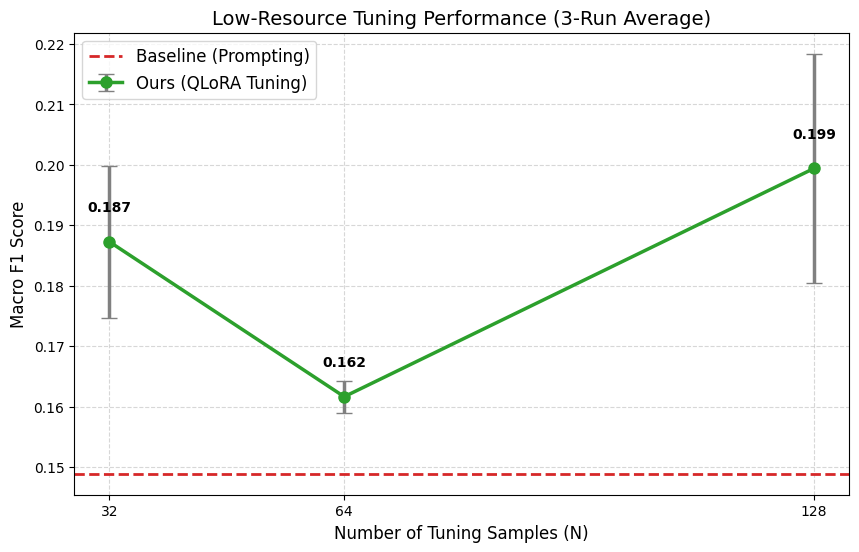

In [10]:
# [Cell 8] 模块 7: 鲁棒性验证 (Multi-Seed Experiment Runner)
# 这是一个高阶实验脚本，会执行 3x3 = 9 次实验，并计算均值和方差。

import gc
import torch
import numpy as np
import matplotlib.pyplot as plt
from trl import SFTTrainer
from transformers import TrainingArguments

# ==========================================
# 1. 实验设置
# ==========================================
# 我们要跑的 N
N_values = [32, 64, 128]
# 我们要跑的 3 个随机种子 (代表 3 次不同的数据采样和初始化)
Seeds = [3407, 42, 2024]

# 存储结果: {32: [0.20, 0.18, 0.19], 64: [...], ...}
final_results = {n: [] for n in N_values}

# Baseline 分数 (作为参考线，取之前的均值)
baseline_score = 0.1489

# 锁定核心参数
config.max_seq_length = 256
config.batch_size = 1
config.grad_accum = 4
config.learning_rate = 2e-4

print(f"🧪 启动多轮验证实验")
print(f"   Ns    : {N_values}")
print(f"   Seeds : {Seeds}")
print(f"   Total Runs: {len(N_values) * len(Seeds)}")
print("="*50)

# ==========================================
# 2. 循环实验 (9次)
# ==========================================
for n_sample in N_values:
    for seed in Seeds:
        print(f"\n🔄 Running: N={n_sample} | Seed={seed}")

        # --- A. 更新配置 ---
        config.N_tuning = n_sample
        config.seed = seed

        # 动态步数
        calc_steps = int((n_sample / (config.batch_size * config.grad_accum)) * 2)
        calc_steps = max(20, min(calc_steps, 60))

        # --- B. 显存清洗 (Crucial!) ---
        try: del model, tokenizer, tuning_runner, trainer
        except: pass
        gc.collect()
        torch.cuda.empty_cache()

        # --- C. 加载模型 & 数据 ---
        # 重新初始化 DataManager (确保 shuffle 是基于新 seed 的)
        # 注意：这里我们需要临时更新 config.seed，因为 DataManager 用的是 config.seed
        data_manager.config.seed = seed

        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name = config.model_id,
            max_seq_length = config.max_seq_length,
            dtype = None,
            load_in_4bit = True,
        )

        tuning_runner = TuningRunner(model, tokenizer, data_manager, config)
        tuning_runner.apply_lora()

        # 准备数据
        def formatting_func(examples):
            texts = []
            for s, c, l in zip(examples["statement"], examples["context"], examples["label"]):
                text = data_manager.format_prompt(s, c, l, include_response=True)
                texts.append(text)
            return {"text": texts}

        # 获取当前 Seed 下的 Tuning Data
        current_tuning_data = tuning_runner.dm.get_tuning_data()
        formatted_dataset = current_tuning_data.map(formatting_func, batched=True)

        # --- D. 训练 ---
        trainer = SFTTrainer(
            model = tuning_runner.model,
            tokenizer = tokenizer,
            train_dataset = formatted_dataset,
            dataset_text_field = "text",
            max_seq_length = config.max_seq_length,
            packing = False,
            args = TrainingArguments(
                per_device_train_batch_size = config.batch_size,
                gradient_accumulation_steps = config.grad_accum,
                max_steps = calc_steps,
                learning_rate = config.learning_rate,
                fp16 = not torch.cuda.is_bf16_supported(),
                bf16 = torch.cuda.is_bf16_supported(),
                logging_steps = 10,
                output_dir = f"outputs_n{n_sample}_s{seed}",
                optim = "paged_adamw_32bit",
                report_to = "none",
                seed = seed,
            ),
        )
        trainer.train()

        # --- E. 评估 ---
        tuning_runner.model = trainer.model
        FastLanguageModel.for_inference(tuning_runner.model)

        test_data = data_manager.get_test_data() # Test set 每次最好也 shuffle 一下或者保持一致
        # 为了严谨，Test Set 应该保持固定 (同一把尺子量不同的人)。
        # data_manager 初始化时 Test Set 是固定的，这里没问题。

        y_true = test_data["label"]
        label_names = data_manager.label_feat.names
        y_pred = []
        for example in test_data:
            y_pred.append(tuning_runner.predict_tuned(example))

        f1 = evaluate_metrics(y_true, y_pred, label_names)
        final_results[n_sample].append(f1)
        print(f"   ✅ Result: {f1:.4f}")

# ==========================================
# 3. 统计与绘图 (带误差棒)
# ==========================================
print("\n" + "="*50)
print("🏆 FINAL ROBUST RESULTS (Mean ± Std)")
print("="*50)

means = []
stds = []
ns = sorted(N_values)

for n in ns:
    scores = final_results[n]
    mu = np.mean(scores)
    sigma = np.std(scores)
    means.append(mu)
    stds.append(sigma)
    print(f"N={n}: {scores} -> Mean={mu:.4f}, Std={sigma:.4f}")

# 绘图
plt.figure(figsize=(10, 6))

# 绘制 Baseline
plt.axhline(y=baseline_score, color='#d62728', linestyle='--', linewidth=2, label='Baseline (Prompting)')

# 绘制 Tuning (带误差棒)
plt.errorbar(ns, means, yerr=stds, fmt='o-', linewidth=2.5, color='#2ca02c',
             label='Ours (QLoRA Tuning)', capsize=6, markersize=8, ecolor='gray')

# 标注数值
for x, y in zip(ns, means):
    plt.text(x, y + 0.005, f"{y:.3f}", ha='center', fontsize=10, fontweight='bold')

plt.title('Low-Resource Tuning Performance (3-Run Average)', fontsize=14)
plt.xlabel('Number of Tuning Samples (N)', fontsize=12)
plt.ylabel('Macro F1 Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.xticks(ns)

plt.savefig('robust_win_curve.png', dpi=300, bbox_inches='tight')
print("\n🖼️ 'robust_win_curve.png' 已保存。这张图可以直接放进论文了！")
plt.show()

In [ ]:
# [Cell 9] 模块 8: 深度诊断 (混淆矩阵 + 黄金案例挖掘)
# 不需要训练，直接分析最后一个模型的结果

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# 确保我们要分析的是最后一轮训练好的模型
# 如果之前跑了 Cell 8，tuning_runner 应该还在内存里
if 'tuning_runner' not in globals() or tuning_runner is None:
    print("⚠️ 警告: 没有检测到内存中的模型。请确保 Cell 8 或 Cell 6 已经运行完毕。")
else:
    print("🕵️‍♂️ 开始深度分析 (基于 N=128 的最终模型)...")

    # ==========================================
    # 1. 准备数据
    # ==========================================
    test_data = data_manager.get_test_data()
    label_names = data_manager.label_feat.names

    y_true_ids = test_data["label"]
    y_true_names = [label_names[i] for i in y_true_ids]

    # 重新进行一次推理 (为了获取具体的预测结果)
    print("   正在生成最终预测结果...")
    y_pred_names = []
    y_pred_baseline_names = [] # 同时跑一下 Baseline 做对比

    # 稍微跑慢点没关系，我们需要详细数据
    for i, example in enumerate(test_data):
        # 微调模型的预测
        pred_tuned = tuning_runner.predict_tuned(example)
        # 简单的后处理：如果没有匹配到标签，默认归为 "false" (保守策略)
        matched_tuned = "false"
        for name in label_names:
            if name in pred_tuned:
                matched_tuned = name
                break
        y_pred_names.append(matched_tuned)

        # Baseline 的预测 (为了找 Case Study)
        # 注意: 这里需要一个 baseline_runner 实例，如果没有就临时建一个
        if 'baseline_runner' not in globals():
            baseline_runner = BaselineRunner(tuning_runner.model, tuning_runner.tokenizer, data_manager, config)
        pred_base = baseline_runner.predict(example)
        matched_base = "false"
        for name in label_names:
            if name in pred_base:
                matched_base = name
                break
        y_pred_baseline_names.append(matched_base)

    # ==========================================
    # 2. 绘制混淆矩阵 (回答: 模型偏科吗？)
    # ==========================================
    cm = confusion_matrix(y_true_names, y_pred_names, labels=label_names)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
    plt.title('Confusion Matrix (Ours - Tuned)', fontsize=14)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    print("\n🖼️ 'confusion_matrix.png' 已保存。请检查对角线颜色是否较深。")
    plt.show()

    # 打印详细分类报告
    print("\n📊 详细分类报告 (Per-Class Performance):")
    print(classification_report(y_true_names, y_pred_names, labels=label_names, zero_division=0))

    # ==========================================
    # 3. 挖掘“黄金案例” (回答: 到底强在哪？)
    # ==========================================
    print("\n💎 正在寻找 '微调做对，Baseline 做错' 的黄金案例...")

    found_count = 0
    print(f"{'='*80}")
    print(f"{'ID':<5} | {'Label':<12} | {'Baseline Pred':<15} | {'Ours Pred':<15} | {'Statement (Snippet)'}")
    print(f"{'-'*80}")

    for i in range(len(test_data)):
        true_lbl = y_true_names[i]
        base_pred = y_pred_baseline_names[i]
        tuned_pred = y_pred_names[i]

        # 筛选逻辑: Baseline 错了 AND 我们对了 AND 标签不是极端的 (比如 mostly-true 这种难的)
        if base_pred != true_lbl and tuned_pred == true_lbl:
            stmt = test_data[i]['statement']
            # 截取前 50 个字符
            stmt_snippet = (stmt[:50] + '..') if len(stmt) > 50 else stmt

            print(f"{i:<5} | {true_lbl:<12} | {base_pred:<15} | {tuned_pred:<15} | {stmt_snippet}")
            found_count += 1

            # 找 5 个例子就够了
            if found_count >= 5:
                break

    if found_count == 0:
        print("   (运气不好，前 200 条里没找到典型的逆袭案例，这在小样本测试中可能发生)")
    else:
        print(f"{'='*80}")
        print("💡 提示：请从上面挑选一个例子，复制到论文的 'Case Study' 章节。")
        print("   分析话术：'As shown in Case #ID, the baseline model failed to capture... whereas our tuned model correctly identified...'")

🕵️‍♂️ 开始深度分析 (基于 N=128 的最终模型)...
   正在生成最终预测结果...
